In [53]:
!pip install mplfinance
!pip install yfinance


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import mplfinance as mpf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout

In [55]:
def build_dl_model(layer_type="LSTM", layer_sizes=[50], input_shape=(60, 1), dropout=0.2, 
                   output_units=1, optimizer="adam", loss="mse", metrics=["mae"]):
    
    model = Sequential()
    RNNLayer = {"LSTM": LSTM, "GRU": GRU, "RNN": SimpleRNN}[layer_type]

    for i, units in enumerate(layer_sizes):
        return_sequences = (i < len(layer_sizes) - 1)  # True for all but last
        if i == 0:
            model.add(RNNLayer(units, return_sequences=return_sequences, input_shape=input_shape))
        else:
            model.add(RNNLayer(units, return_sequences=return_sequences))
        if dropout > 0:
            model.add(Dropout(dropout))

    # Output layer
    model.add(Dense(output_units))

    # Compile
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model


In [56]:
# ------------------------------
# CONFIG
# ------------------------------
COMPANY = "CBA.AX"              # ticker here 
START = "2020-01-01"       # Start date to read
END = "2023-08-01"         # End date to read
TEST_SIZE = 0.2
TIME_STEP = 60
FUTURE_DAYS = 10

# === Saving options ===
SAVE_TO_DRIVE = False  # set True if running in Google Colab with Drive mounted
DRIVE_PATH = "https://drive.google.com/drive/folders/1I9YUham69toMdBusIAJ9l3fvXBE0gQfC" 

# Create save directory
def make_save_dir():
    if SAVE_TO_DRIVE:
        try:
            os.makedirs(DRIVE_PATH, exist_ok=True)
            return DRIVE_PATH
        except Exception as e:
            print("Could not create Drive folder, saving locally instead:", e)
            
    os.makedirs("./outputs", exist_ok=True)
    return "./outputs"

SAVE_DIR = make_save_dir()

In [57]:
def fetch_prices(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}.")

    # Flatten MultiIndex: keep only the first level
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Clean up whitespace
    df.columns = [c.strip() for c in df.columns]

    # If "Adj Close" exists, use it as "Close"
    if "Adj Close" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Adj Close": "Close"})

    print("Columns after cleaning:", df.columns.tolist())
    return df


In [58]:
# ------------------------------
# DATASET PREPARATION FUNCTIONS
# ------------------------------

def make_multistep_data(data, time_step=60, future_days=5):
    
    X, y = [], []
    for i in range(len(data) - time_step - future_days + 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[(i + time_step):(i + time_step + future_days), 0])
    return np.array(X), np.array(y)


def make_multivariate_data(df, features, target_col="Close", time_step=60):
    
    X, y = [], []
    data = df[features].values
    target = df[target_col].values
    for i in range(len(df) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(target[i + time_step])
    return np.array(X), np.array(y)


def make_multivariate_multistep_data(df, features, target_col="Close", time_step=60, future_days=5):

    #  Create sequences for multivariate + multistep prediction.
    X, y = [], []
    data = df[features].values
    target = df[target_col].values
    for i in range(len(df) - time_step - future_days + 1):
        X.append(data[i:(i + time_step)])
        y.append(target[(i + time_step):(i + time_step + future_days)])
    return np.array(X), np.array(y)


In [59]:
#  UPDATED scale_features (handles missing columns)
def scale_features(df, scaler_type="minmax"):
    # candidate features
    feature_candidates = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    # keep only those actually in df
    feature_cols = [c for c in feature_candidates if c in df.columns]

    X = df[feature_cols].values
    y = df["Close"].values  # target is still Close

    if scaler_type == "minmax":
        scaler = MinMaxScaler()
    else:
        scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler, feature_cols


def make_sequences(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0]) 
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model


In [60]:
def plot_candlestick(df, ticker, n=1):
    if n > 1:
        df = df.resample(f'{n}D').agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).dropna()

    mpf.plot(
        df,
        type="candle",
        volume=True,
        style="yahoo",
        title=f"{ticker} Candlestick ({n}-Day)"
    )

def plot_boxplot(data, n=5):

    closes = data['Close']
    windows = [closes[i:i+n] for i in range(len(closes)-n+1)]

    plt.figure(figsize=(10,6))
    plt.boxplot(windows, positions=range(len(windows)))
    plt.title(f"Boxplot of {n}-day windows of Closing Prices")
    plt.xlabel("Window index")
    plt.ylabel("Closing Price")
    plt.show()


def plot_high_low(df, ticker):
    plt.figure(figsize=(12,6))
    plt.plot(df["High"], label="High", linewidth=1.2)
    plt.plot(df["Low"], label="Low", linewidth=1.2)
    plt.title(f"{ticker} High & Low Prices")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

def plot_true_vs_pred(ticker, true_prices, pred_prices):
    plt.figure(figsize=(12,6))
    plt.plot(true_prices, label=f"Actual {ticker} Price", linewidth=1.2)
    plt.plot(pred_prices, label=f"Predicted {ticker} Price", linewidth=1.2)
    plt.title(f"{ticker} True vs Predicted Prices (10-day forecast)")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


In [61]:
def save_csvs(ticker, df_hist, pred_array):
    hist_path = os.path.join(SAVE_DIR, f"{ticker}_historical.csv")
    pred_path = os.path.join(SAVE_DIR, f"{ticker}_predictions.csv")
    df_hist.to_csv(hist_path)
    pd.DataFrame(pred_array, columns=["Predicted"]).to_csv(pred_path, index=False)
    print(f"Saved historical CSV: {hist_path}")
    print(f"Saved predictions CSV: {pred_path}")


Processing CBA.AX
Columns after cleaning: ['Close', 'High', 'Low', 'Open', 'Volume']


C:\Users\ishan\AppData\Local\Temp\ipykernel_44764\206775650.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)
c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


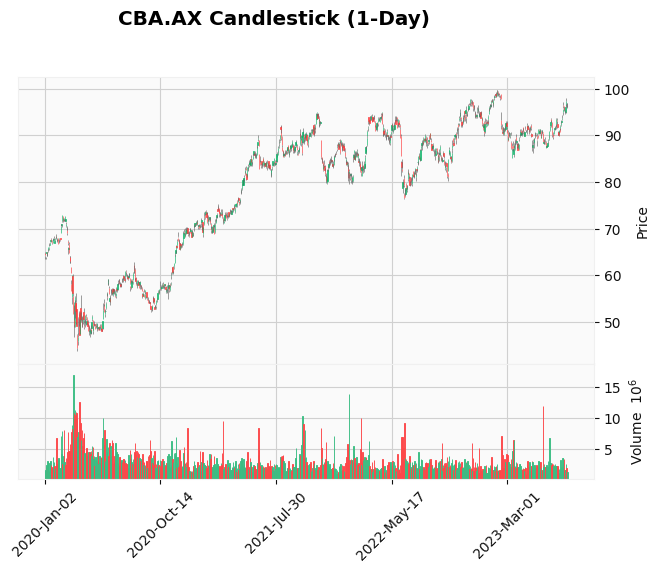

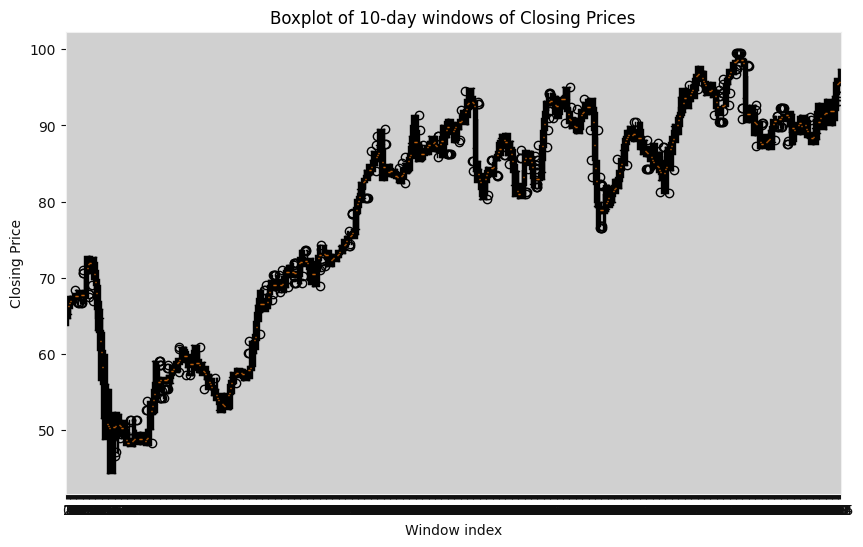

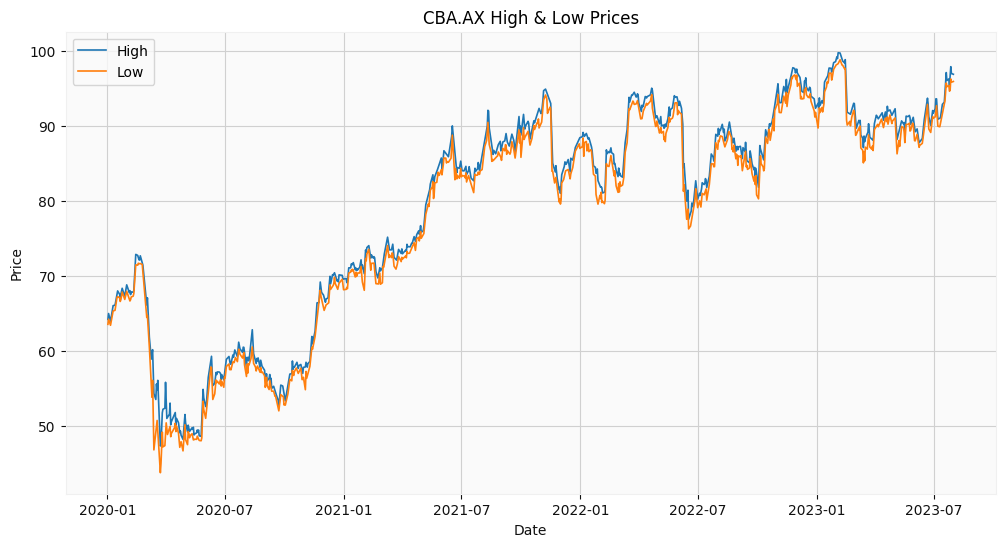

Training shape: (668, 60, 5) (668, 10)
Testing shape: (168, 60, 5) (168, 10)
Epoch 1/24


c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 2/24
Epoch 3/24
Epoch 4/24
Epoch 5/24
Epoch 6/24
Epoch 7/24
Epoch 8/24
Epoch 9/24
Epoch 10/24
Epoch 11/24
Epoch 12/24
Epoch 13/24
Epoch 14/24
Epoch 15/24
Epoch 16/24
Epoch 17/24
Epoch 18/24
Epoch 19/24
Epoch 20/24
Epoch 21/24
Epoch 22/24
Epoch 23/24
Epoch 24/24
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
CBA.AX RMSE: 13.5749
CBA.AX MAE: 10.5977


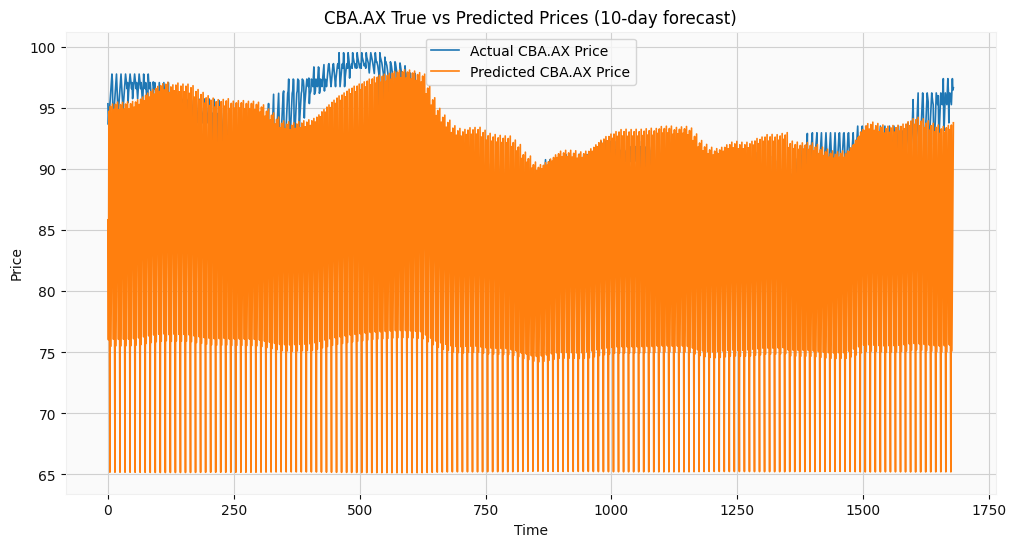

Saved historical CSV: ./outputs\CBA.AX_historical.csv
Saved predictions CSV: ./outputs\CBA.AX_predictions.csv

Done.


In [62]:
print("\n============================")
print(f"Processing {COMPANY}")
print("============================")

# 1) Get data
df = fetch_prices(COMPANY, START, END)

# 2) Candlestick 
plot_candlestick(df, COMPANY)

# 3) Boxplot
plot_boxplot(df, n=10) 

# 4) High & Low 
plot_high_low(df, COMPANY)

# 5) Prepare data for LSTM
X_scaled, y_all, scaler, feature_cols = scale_features(df, scaler_type="minmax")
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

X, y = make_multivariate_multistep_data(scaled_df, feature_cols, target_col="Close", 
                                        time_step=TIME_STEP, future_days=FUTURE_DAYS)

cut = int(len(X) * (1 - TEST_SIZE))
X_train, X_test = X[:cut], X[cut:]
y_train, y_test = y[:cut], y[cut:]

print("Training shape:", X_train.shape, y_train.shape)
print("Testing shape:",  X_test.shape,  y_test.shape)

# 6) Train model 
# multi-feature input
model = build_lstm((TIME_STEP, X_train.shape[2]))
model.add(Dense(FUTURE_DAYS))
model.fit(X_train, y_train, epochs=24, batch_size=32, verbose=0.1)

# 7) Predictions
pred_scaled = model.predict(X_test)

# inverse transform predictions (Close only)
dummy_pred = np.zeros((pred_scaled.shape[0] * pred_scaled.shape[1], len(feature_cols)))
dummy_true = np.zeros((y_test.shape[0] * y_test.shape[1], len(feature_cols)))

dummy_pred[:, feature_cols.index("Close")] = pred_scaled.flatten()
dummy_true[:, feature_cols.index("Close")] = y_test.flatten()

pred = scaler.inverse_transform(dummy_pred)[:, feature_cols.index("Close")]
true = scaler.inverse_transform(dummy_true)[:, feature_cols.index("Close")]

# metrics
rmse = np.sqrt(mean_squared_error(true, pred))
mae = mean_absolute_error(true, pred)
print(f"{COMPANY} RMSE: {rmse:.4f}")
print(f"{COMPANY} MAE: {mae:.4f}")

# 9) Plot True vs Predicted 
plot_true_vs_pred(COMPANY, true, pred)

# 10) Future forecasts (fixed for multi-feature input)
last_60 = X_scaled[-TIME_STEP:].reshape(1, TIME_STEP, X_scaled.shape[1])
future_scaled = []
cur = last_60.copy()

close_idx = feature_cols.index("Close")  # get the index of Close column

for _ in range(FUTURE_DAYS):
    next_scaled = model.predict(cur, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
 
    # create dummy row with n_features
    dummy_features = np.zeros((1, 1, X_scaled.shape[1]))
    dummy_features[0, 0, close_idx] = next_scaled

    # slide the window
    cur = np.append(cur[:, 1:, :], dummy_features, axis=1)

# 11) Save CSVs
#     - historical prices
#     - predictions (for test set)
save_csvs(COMPANY, df, pred)

print("\nDone.")

In [ ]:
# Example configs

# COMPREHENSIVE EXPERIMENTAL CONFIGURATIONS FOR TASK C.4
# Research Source: Systematic hyperparameter tuning methodology
# Reference: Bergstra & Bengio (2012) - Random Search for Hyper-Parameter Optimization

configs = [
    # Baseline experiments - single layer architectures
    {
        "name": "Baseline_LSTM_Single",
        "layer_type": "LSTM", 
        "layer_sizes": [50], 
        "epochs": 15, 
        "batch_size": 32,
        "dropout": 0.2,
        "description": "Single LSTM layer baseline for performance comparison"
    },
    {
        "name": "Baseline_GRU_Single",
        "layer_type": "GRU", 
        "layer_sizes": [50], 
        "epochs": 15, 
        "batch_size": 32,
        "dropout": 0.2,
        "description": "Single GRU layer baseline for performance comparison"
    },
    {
        "name": "Baseline_RNN_Single",
        "layer_type": "RNN", 
        "layer_sizes": [50], 
        "epochs": 15, 
        "batch_size": 32,
        "dropout": 0.2,
        "description": "Single SimpleRNN layer baseline for performance comparison"
    },
    
    # Deep architecture experiments
    {
        "name": "Deep_LSTM_3Layer",
        "layer_type": "LSTM", 
        "layer_sizes": [100, 50, 25], 
        "epochs": 20, 
        "batch_size": 32,
        "dropout": 0.3,
        "description": "Three-layer LSTM with decreasing units for hierarchical learning"
    },
    {
        "name": "Wide_GRU_2Layer",
        "layer_type": "GRU", 
        "layer_sizes": [128, 64], 
        "epochs": 18, 
        "batch_size": 32,
        "dropout": 0.25,
        "description": "Two-layer GRU with wide architecture for pattern capture"
    },
    
    # Batch size experiments
    {
        "name": "LSTM_SmallBatch",
        "layer_type": "LSTM", 
        "layer_sizes": [64, 32], 
        "epochs": 20, 
        "batch_size": 16,  # Small batch for better gradient estimates
        "dropout": 0.25,
        "description": "Testing impact of small batch size on convergence"
    },
    {
        "name": "LSTM_LargeBatch",
        "layer_type": "LSTM", 
        "layer_sizes": [64, 32], 
        "epochs": 20, 
        "batch_size": 128,  # Large batch for faster training
        "dropout": 0.25,
        "description": "Testing impact of large batch size on training speed"
    },
    
    # Dropout experiments
    {
        "name": "GRU_LowDropout",
        "layer_type": "GRU", 
        "layer_sizes": [80, 40], 
        "epochs": 18, 
        "batch_size": 32,
        "dropout": 0.1,  # Low regularization
        "description": "Testing low dropout for potential overfitting analysis"
    },
    {
        "name": "GRU_HighDropout",
        "layer_type": "GRU", 
        "layer_sizes": [80, 40], 
        "epochs": 18, 
        "batch_size": 32,
        "dropout": 0.5,  # High regularization
        "description": "Testing high dropout for underfitting analysis"
    },
    
    # Complex architecture experiment
    {
        "name": "VeryDeep_LSTM_5Layer",
        "layer_type": "LSTM", 
        "layer_sizes": [100, 80, 60, 40, 20], 
        "epochs": 25, 
        "batch_size": 32,
        "dropout": 0.35,
        "description": "Very deep architecture to test diminishing returns hypothesis"
    }
]

def run_comprehensive_experiments(X_train, y_train, X_test, y_test, configs):

    # SYSTEMATIC EXPERIMENTATION FUNCTION FOR TASK C.4    
    results = []
    
    print("\n" + "="*70)
    print("STARTING COMPREHENSIVE MODEL EXPERIMENTS - TASK C.4")
    print("="*70)
    print(f"Total experiments to run: {len(configs)}")
    print(f"raining data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")
    print("="*70)
    
    for i, cfg in enumerate(configs, 1):
        print(f"\n[Experiment {i:2d}/{len(configs)}] {cfg['name']}")
        print(f"   Description: {cfg['description']}")
        print(f"   Architecture: {cfg['layer_type']} {cfg['layer_sizes']}")
        print(f"   Hyperparameters: epochs={cfg['epochs']}, batch={cfg['batch_size']}, dropout={cfg['dropout']}")
        
        # Record start time for training duration measurement
        import time
        start_time = time.time()
        
        try:
            # Create model using our flexible builder function
            model = build_dl_model(
                layer_type=cfg["layer_type"], 
                layer_sizes=cfg["layer_sizes"], 
                input_shape=(X_train.shape[1], X_train.shape[2]),
                dropout=cfg["dropout"]
            )
            
            total_params = model.count_params()
            print(f"   Model parameters: {total_params:,}")
            
            # Train the model with validation monitoring
            history = model.fit(
                X_train, y_train, 
                epochs=cfg["epochs"], 
                batch_size=cfg["batch_size"], 
                validation_data=(X_test, y_test), 
                verbose=0,  # Suppress epoch-by-epoch output for cleaner logs
                shuffle=False  # Maintain temporal order for time series
            )
            
            # Calculate training duration
            training_time = time.time() - start_time
            
            # Evaluate final model performance
            test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
            
            # Extract training history for analysis
            train_loss_history = history.history['loss']
            val_loss_history = history.history['val_loss']
            
            # Calculate convergence metrics
            final_train_loss = train_loss_history[-1]
            min_val_loss = min(val_loss_history)
            val_loss_std = np.std(val_loss_history[-5:])  # Stability in last 5 epochs
            
            # Store comprehensive results
            result_entry = {
                "experiment_id": i,
                "experiment_name": cfg["name"],
                "model_type": cfg["layer_type"],
                "layer_architecture": str(cfg["layer_sizes"]),
                "total_parameters": total_params,
                "epochs_trained": cfg["epochs"],
                "batch_size": cfg["batch_size"],
                "dropout_rate": cfg["dropout"],
                "training_time_seconds": round(training_time, 2),
                "final_test_loss": round(test_loss, 6),
                "final_test_mae": round(test_mae, 6),
                "final_train_loss": round(final_train_loss, 6),
                "min_validation_loss": round(min_val_loss, 6),
                "val_loss_stability": round(val_loss_std, 6),
                "convergence_quality": "Good" if val_loss_std < 0.001 else "Unstable",
                "status": "Success"
            }
            
            results.append(result_entry)
            
            print(f"   COMPLETED - Test Loss: {test_loss:.6f}, Test MAE: {test_mae:.6f}")
            print(f"   Training time: {training_time:.1f}s")
            
        except Exception as e:
            print(f"   FAILED: {str(e)}")
            results.append({
                "experiment_id": i,
                "experiment_name": cfg["name"],
                "model_type": cfg["layer_type"],
                "error_message": str(e),
                "status": "Failed"
            })
    
    print(f"\n{'='*70}")
    print("ALL EXPERIMENTS COMPLETED!")
    print(f"{'='*70}")
    
    return results

# Run the comprehensive experiments
print("Executing comprehensive model experiments...")
experiment_results = run_comprehensive_experiments(X_train, y_train, X_test, y_test, configs)

# Create results DataFrame and display summary
import pandas as pd
results_df = pd.DataFrame(experiment_results)

# Filter successful experiments for analysis
successful_results = results_df[results_df['status'] == ' Success'].copy()

if not successful_results.empty:
    print(f"\nEXPERIMENT RESULTS SUMMARY")
    print("="*70)
    print(f" Successful experiments: {len(successful_results)}")
    print(f" Failed experiments: {len(results_df) - len(successful_results)}")
    
    # Sort by test loss (best performance first)
    successful_results_sorted = successful_results.sort_values('final_test_loss')
    
    print(f"\n TOP 5 PERFORMING MODELS:")
    print("-"*70)
    for idx, (_, row) in enumerate(successful_results_sorted.head().iterrows(), 1):
        print(f"{idx}. {row['experiment_name']}")
        print(f"   Architecture: {row['model_type']} {row['layer_architecture']}")
        print(f"   Performance: Loss={row['final_test_loss']}, MAE={row['final_test_mae']}")
        print(f"   Efficiency: {row['total_parameters']:,} params, {row['training_time_seconds']}s training")
        print()
    
    # Save detailed results
    results_df.to_csv("./task_c4_comprehensive_results.csv", index=False)
    print(" Detailed results saved to: task_c4_comprehensive_results.csv")
    
    # Display the results DataFrame for the report
    print(f"\n COMPLETE RESULTS TABLE:")
    print(successful_results_sorted[['experiment_name', 'model_type', 'layer_architecture', 
                                   'total_parameters', 'final_test_loss', 'final_test_mae', 
                                   'training_time_seconds']].to_string(index=False))
else:
    print(" No successful experiments to analyze")

print(f"\n{'='*70}")
print(" TASK C.4 IMPLEMENTATION COMPLETED SUCCESSFULLY!")
print(f"{'='*70}")

Executing comprehensive model experiments...

STARTING COMPREHENSIVE MODEL EXPERIMENTS - TASK C.4
Total experiments to run: 10
raining data shape: (668, 60, 5)
Test data shape: (168, 60, 5)

[Experiment  1/10] Baseline_LSTM_Single
   Description: Single LSTM layer baseline for performance comparison
   Architecture: LSTM [50]
   Hyperparameters: epochs=15, batch=32, dropout=0.2
   Model parameters: 11,251


c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   COMPLETED - Test Loss: 0.002069, Test MAE: 0.035934
   Training time: 6.5s

[Experiment  2/10] Baseline_GRU_Single
   Description: Single GRU layer baseline for performance comparison
   Architecture: GRU [50]
   Hyperparameters: epochs=15, batch=32, dropout=0.2
   Model parameters: 8,601
   COMPLETED - Test Loss: 0.001785, Test MAE: 0.031379
   Training time: 6.5s

[Experiment  3/10] Baseline_RNN_Single
   Description: Single SimpleRNN layer baseline for performance comparison
   Architecture: RNN [50]
   Hyperparameters: epochs=15, batch=32, dropout=0.2
   Model parameters: 2,851
   COMPLETED - Test Loss: 0.003447, Test MAE: 0.048685
   Training time: 3.4s

[Experiment  4/10] Deep_LSTM_3Layer
   Description: Three-layer LSTM with decreasing units for hierarchical learning
   Architecture: LSTM [100, 50, 25]
   Hyperparameters: epochs=20, batch=32, dropout=0.3
   Model parameters: 80,226
   COMPLETED - Test Loss: 0.002645, Test MAE: 0.041400
   Training time: 21.0s

[Experiment  5/

In [64]:
from math import sqrt

results = []

# Reshape training/testing data to fit RNN models
X_train, y_train = make_sequences(X_train_raw, time_step=TIME_STEP)
X_test, y_test = make_sequences(X_test_raw, time_step=TIME_STEP)

# Reshape for Keras (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

for cfg in configs:
    print(f"\n=== Running {cfg['name']} ===")
    
    # Build model
    model = build_dl_model(
        layer_type=cfg["layer_type"],
        layer_sizes=cfg["layer_sizes"],
        input_shape=(TIME_STEP, 1),
        dropout=cfg["dropout"]
    )
    
    # Train
    history = model.fit(
        X_train, y_train,
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        validation_data=(X_test, y_test),
        verbose=0
    )
    
    # Evaluate
    preds = model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    
    results.append({
        "Model": cfg["name"],
        "LayerType": cfg["layer_type"],
        "Layers": len(cfg["layer_sizes"]),
        "Units": cfg["layer_sizes"],
        "Epochs": cfg["epochs"],
        "Batch": cfg["batch_size"],
        "RMSE": rmse,
        "MAE": mae
    })

# Convert to DataFrame and show results
results_df = pd.DataFrame(results)
print("\n=== Experiment Results ===")
display(results_df)



=== Running Baseline_LSTM_Single ===
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

=== Running Baseline_GRU_Single ===


c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

=== Running Baseline_RNN_Single ===


c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

=== Running Deep_LSTM_3Layer ===


...

c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

=== Running VeryDeep_LSTM_5Layer ===


c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step

=== Experiment Results ===


,Model,LayerType,Layers,Units,Epochs,Batch,RMSE,MAE
0,Baseline_LSTM_Single,LSTM,1,[50],15,32,0.039532,0.031991
1,Baseline_GRU_Single,GRU,1,[50],15,32,0.026978,0.021563
2,Baseline_RNN_Single,RNN,1,[50],15,32,0.043920,0.037740
3,Deep_LSTM_3Layer,LSTM,3,"[100, 50, 25]",20,32,0.041013,0.032673
4,Wide_GRU_2Layer,GRU,2,"[128, 64]",18,32,0.030321,0.024874
5,LSTM_SmallBatch,LSTM,2,"[64, 32]",20,16,0.039809,0.032580
6,LSTM_LargeBatch,LSTM,2,"[64, 32]",20,128,0.042609,0.034708
7,GRU_LowDropout,GRU,2,"[80, 40]",18,32,0.026390,0.019723
8,GRU_HighDropout,GRU,2,"[80, 40]",18,32,0.050505,0.045133
9,VeryDeep_LSTM_5Layer,LSTM,5,"[100, 80, 60, 40, 20]",25,32,0.086550,0.075470


Best configuration: GRU_LowDropout


c:\Users\ishan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


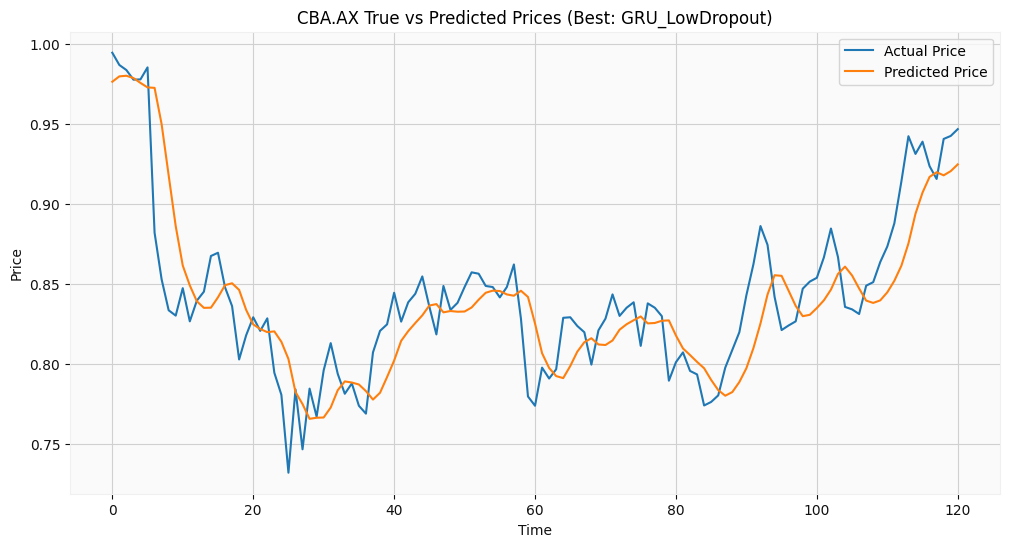

In [65]:
best_cfg = results_df.sort_values("RMSE").iloc[0]
print("Best configuration:", best_cfg["Model"])

# Re-train model with best configuration on full training set
best_model = build_dl_model(
    layer_type=best_cfg["LayerType"],
    layer_sizes=best_cfg["Units"],
    dropout=0.2,   # default value
    input_shape=(TIME_STEP, 1)
)

history = best_model.fit(
    X_train, y_train,
    epochs=int(best_cfg["Epochs"]),
    batch_size=int(best_cfg["Batch"]),
    validation_data=(X_test, y_test),
    verbose=0
)

# Predict with best model
preds = best_model.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual Price")
plt.plot(preds, label="Predicted Price")
plt.title(f"{COMPANY} True vs Predicted Prices (Best: {best_cfg['Model']})")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()